In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import HTML, display

# NFL Edge Dictionary

In [5]:
!rm -rf data
!mkdir data

In [6]:
!cp -r ~/Code/nfl-ai/Scrapers/data/* data/

### Opponent Stats/ATS After Playing DET Lions

Season,Lions SU,Lions ATS,Opponents Next SU,Opponents Next ATS,Fade Opponents ATS
2022,9-8-0,12-5-0,9-7-0,7-8-1,8-7-1
2023,14-6-0,14-6-0,8-9-0,7-9-1,9-7-1
2024,15-3-0,12-5-1,6-12-0,4-13-1,13-4-1
2025,9-8-0,8-9-0,7-10-0,9-8-0,8-9-0


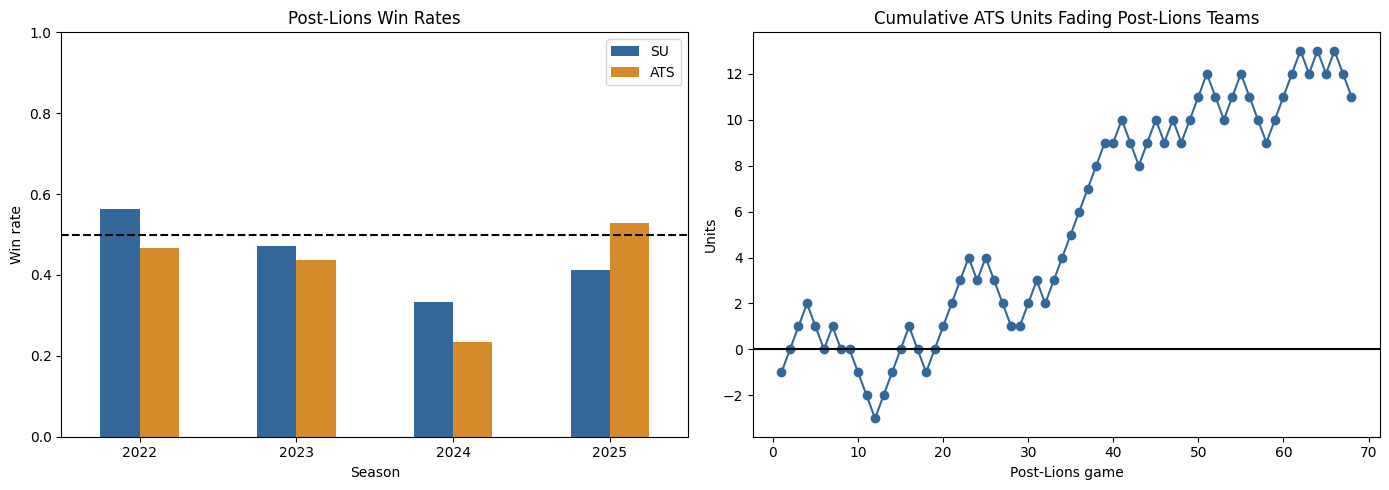

In [20]:
# python scripts/lions_postgame_trends.py


TEAM = "DET"
SEASONS = range(2022, 2027)

# Completed regular-season and playoff games
g = pd.read_csv("data/games.csv", parse_dates=["date"])

g = g[
    g.season.isin(SEASONS)
    & g.home_score.notna()
    & g.away_score.notna()
    & g.spread_line.notna()
    & g.game_type.ne("PRE")
].copy()

# Find Lions games
lions = g[
    g.home_team.eq(TEAM) | g.away_team.eq(TEAM)
].sort_values("date")

lions_rows = []
post_rows = []

for _, game in lions.iterrows():
    opponent = (
        game.away_team
        if game.home_team == TEAM
        else game.home_team
    )

    # Grade the Lions game
    home = game.home_team == TEAM
    margin = (
        (game.home_score - game.away_score)
        * (1 if home else -1)
    )
    ats_margin = margin + (
        -game.spread_line if home else game.spread_line
    )

    lions_rows.append({
        "Season": game.season,
        "SU": "W" if margin > 0 else "L" if margin < 0 else "T",
        "ATS": "W" if ats_margin > 0 else "L" if ats_margin < 0 else "P",
    })

    # Find the opponent's next game
    next_games = g[
        g.season.eq(game.season)
        & g.date.gt(game.date)
        & (
            g.home_team.eq(opponent)
            | g.away_team.eq(opponent)
        )
    ].sort_values("date")

    if next_games.empty:
        continue

    next_game = next_games.iloc[0]

    # Grade the opponent's next game
    home = next_game.home_team == opponent
    margin = (
        (next_game.home_score - next_game.away_score)
        * (1 if home else -1)
    )
    ats_margin = margin + (
        -next_game.spread_line
        if home
        else next_game.spread_line
    )

    post_rows.append({
        "Season": game.season,
        "Week vs DET": game.week,
        "Opponent": opponent,
        "Next Date": next_game.date.date(),
        "Next Opponent": (
            next_game.away_team
            if home
            else next_game.home_team
        ),
        "Venue": "Home" if home else "Away",
        "SU": "W" if margin > 0 else "L" if margin < 0 else "T",
        "ATS": "W" if ats_margin > 0 else "L" if ats_margin < 0 else "P",
    })

lions_results = pd.DataFrame(lions_rows)
post = pd.DataFrame(post_rows)

# Build season summary
summary_rows = []

for season in sorted(lions_results.Season.unique()):
    det = lions_results[lions_results.Season == season]
    opponents = post[post.Season == season]

    det_su = det.SU.value_counts()
    det_ats = det.ATS.value_counts()
    post_su = opponents.SU.value_counts()
    post_ats = opponents.ATS.value_counts()

    summary_rows.append({
        "Season": season,
        "Lions SU": (
            f"{det_su.get('W', 0)}-"
            f"{det_su.get('L', 0)}-"
            f"{det_su.get('T', 0)}"
        ),
        "Lions ATS": (
            f"{det_ats.get('W', 0)}-"
            f"{det_ats.get('L', 0)}-"
            f"{det_ats.get('P', 0)}"
        ),
        "Opponents Next SU": (
            f"{post_su.get('W', 0)}-"
            f"{post_su.get('L', 0)}-"
            f"{post_su.get('T', 0)}"
        ),
        "Opponents Next ATS": (
            f"{post_ats.get('W', 0)}-"
            f"{post_ats.get('L', 0)}-"
            f"{post_ats.get('P', 0)}"
        ),
        "Fade Opponents ATS": (
            f"{post_ats.get('L', 0)}-"
            f"{post_ats.get('W', 0)}-"
            f"{post_ats.get('P', 0)}"
        ),
    })

summary = pd.DataFrame(summary_rows)

# Centered and formatted summary table
summary_table = (
    summary.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "center",
        "padding": "8px 14px",
        "border-bottom": "1px solid #e5e7eb",
    })
    .set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("font-size", "13px"),
            ],
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("background", "#f3f4f6"),
                ("padding", "10px 14px"),
                ("border-bottom", "2px solid #9ca3af"),
            ],
        },
        {
            "selector": "tbody tr:nth-child(even)",
            "props": [("background", "#f9fafb")],
        },
    ])
    .to_html()
)

display(HTML(
    f"""
    <div style="
        display:flex;
        justify-content:center;
        width:100%;
        margin:8px 0 12px 0;
    ">
        {summary_table}
    </div>
    """
))

if 2026 not in lions_results.Season.unique():
    pass

# Detailed tables: All seasons plus one tab per season
tables = [("All", post)] + [
    (str(season), post[post.Season == season])
    for season in sorted(post.Season.unique())
]

css = """
<style>
.post-table {
    margin: 0 auto;
    border-collapse: collapse;
    font-family: Arial, sans-serif;
    font-size: 13px;
}
.post-table th {
    padding: 10px 14px;
    text-align: center;
    background: #f3f4f6;
    border-bottom: 2px solid #9ca3af;
    position: sticky;
    top: 0;
}
.post-table td {
    padding: 8px 14px;
    text-align: center;
    border-bottom: 1px solid #e5e7eb;
}
.post-table tr:nth-child(even) {
    background: #f9fafb;
}
.post-table tr:hover {
    background: #eef4fb;
}
</style>
"""

tabs = widgets.Tab(
    layout=widgets.Layout(width="100%")
)

tabs.children = tuple(
    widgets.HTML(
        css
        + f"""
          <p style="text-align:center">
            <b>{len(table)} post-Lions games</b>
          </p>
          <div style="
              max-height:360px;
              overflow:auto;
              text-align:center;
          ">
              {table.to_html(index=False, classes="post-table")}
          </div>
        """
    )
    for _, table in tables
)

for i, (name, _) in enumerate(tables):
    tabs.set_title(i, name)

# Starts collapsed
accordion = widgets.Accordion(
    children=[tabs],
    selected_index=None,
    layout=widgets.Layout(width="95%"),
)

accordion.set_title(
    0,
    f"Post-Lions Detailed Games ({len(post)}) — click to expand",
)

display(
    widgets.VBox(
        [accordion],
        layout=widgets.Layout(
            width="100%",
            align_items="center",
        ),
    )
)

# Win-rate calculations without functions
post["SU Win"] = post.SU.eq("W").astype(int)
post["SU Decision"] = post.SU.ne("T").astype(int)
post["ATS Win"] = post.ATS.eq("W").astype(int)
post["ATS Decision"] = post.ATS.ne("P").astype(int)

totals = post.groupby("Season")[
    ["SU Win", "SU Decision", "ATS Win", "ATS Decision"]
].sum()

rates = pd.DataFrame({
    "SU": totals["SU Win"] / totals["SU Decision"],
    "ATS": totals["ATS Win"] / totals["ATS Decision"],
})

post = post.sort_values("Next Date")
post["Fade Unit"] = post.ATS.map({
    "L": 1,
    "W": -1,
    "P": 0,
})
post["Cumulative Fade Units"] = post["Fade Unit"].cumsum()

# Charts
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)

rates.plot.bar(
    ax=axes[0],
    color=["#35689a", "#d58b2b"],
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
)

axes[0].set(
    title="Post-Lions Win Rates",
    xlabel="Season",
    ylabel="Win rate",
    ylim=(0, 1),
)

axes[0].tick_params(
    axis="x",
    rotation=0,
)

axes[1].plot(
    range(1, len(post) + 1),
    post["Cumulative Fade Units"],
    marker="o",
    color="#35689a",
)

axes[1].axhline(
    0,
    color="black",
)

axes[1].set(
    title="Cumulative ATS Units Fading Post-Lions Teams",
    xlabel="Post-Lions game",
    ylabel="Units",
)

plt.tight_layout()
plt.show()